In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss, classification_report

# Load data 
df = pd.read_csv('Task 3 and 4_Loan_Data.csv')
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn info:")
print(df.info())
print("\nBasic statistics:")
print(df.describe())


Dataset shape: (10000, 8)

First 5 rows:
   customer_id  credit_lines_outstanding  loan_amt_outstanding  \
0      8153374                         0           5221.545193   
1      7442532                         5           1958.928726   
2      2256073                         0           3363.009259   
3      4885975                         0           4766.648001   
4      4700614                         1           1345.827718   

   total_debt_outstanding       income  years_employed  fico_score  default  
0             3915.471226  78039.38546               5         605        0  
1             8228.752520  26648.43525               2         572        1  
2             2027.830850  65866.71246               4         602        0  
3             2501.730397  74356.88347               5         612        0  
4             1768.826187  23448.32631               6         631        0  

Column info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data 


Missing values:
customer_id                 0
credit_lines_outstanding    0
loan_amt_outstanding        0
total_debt_outstanding      0
income                      0
years_employed              0
fico_score                  0
default                     0
dtype: int64

Default rate: 18.51%
Defaulters: 1851
Non-defaulters: 8149


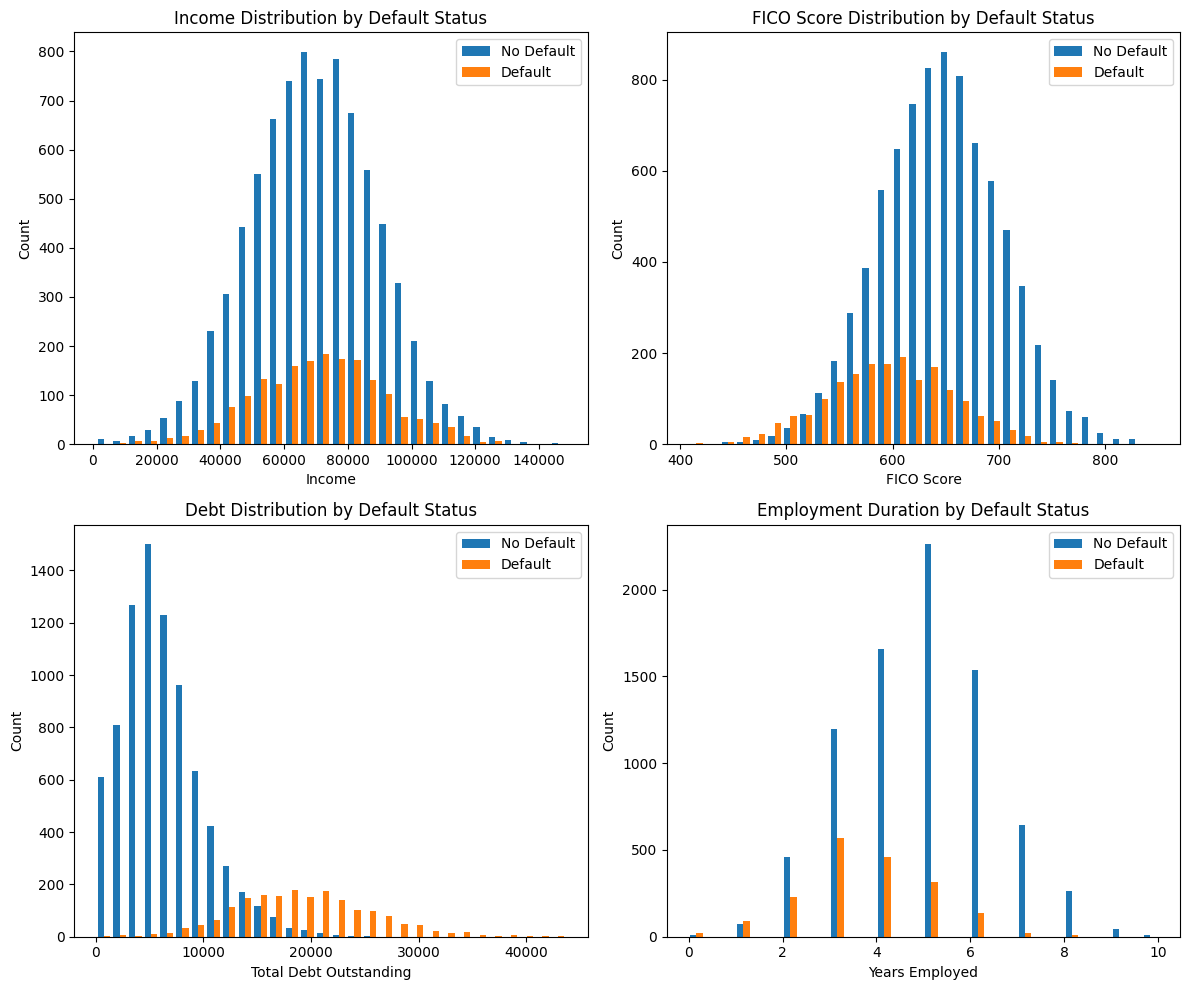

In [3]:
# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

# Check default rate
default_rate = df['default'].mean()
print(f"\nDefault rate: {default_rate:.2%}")
print(f"Defaulters: {df['default'].sum()}")
print(f"Non-defaulters: {(df['default']==0).sum()}")

# Visualize some relationships
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Income vs Default
axes[0, 0].hist([df[df['default']==0]['income'], df[df['default']==1]['income']], 
                label=['No Default', 'Default'], bins=30)
axes[0, 0].set_xlabel('Income')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('Income Distribution by Default Status')
axes[0, 0].legend()

# FICO Score vs Default
axes[0, 1].hist([df[df['default']==0]['fico_score'], df[df['default']==1]['fico_score']], 
                label=['No Default', 'Default'], bins=30)
axes[0, 1].set_xlabel('FICO Score')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('FICO Score Distribution by Default Status')
axes[0, 1].legend()

# Total Debt vs Default
axes[1, 0].hist([df[df['default']==0]['total_debt_outstanding'], 
                 df[df['default']==1]['total_debt_outstanding']], 
                label=['No Default', 'Default'], bins=30)
axes[1, 0].set_xlabel('Total Debt Outstanding')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('Debt Distribution by Default Status')
axes[1, 0].legend()

# Years Employed vs Default
axes[1, 1].hist([df[df['default']==0]['years_employed'], 
                 df[df['default']==1]['years_employed']], 
                label=['No Default', 'Default'], bins=30)
axes[1, 1].set_xlabel('Years Employed')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Employment Duration by Default Status')
axes[1, 1].legend()

plt.tight_layout()
plt.show()


In [5]:
# Separate features (X) and target (y)
# Drop customer_id because it's just an identifier, not a predictor
X = df.drop(['customer_id', 'default'], axis=1)
y = df['default']

print("Features (X):", X.columns.tolist())
print("Target (y):", y.name)

# Split into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")

# Scale features (important for Logistic Regression)
# This normalizes values so income (large numbers) and years_employed (small numbers) 
# are on the same scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nData preparation complete!")


Features (X): ['credit_lines_outstanding', 'loan_amt_outstanding', 'total_debt_outstanding', 'income', 'years_employed', 'fico_score']
Target (y): default

Training set: 8000 samples
Testing set: 2000 samples

Data preparation complete!


In [6]:
print("=== Training Logistic Regression ===")

# Create and train the model
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

# Make predictions
lr_pred = lr_model.predict(X_test_scaled)  # 0 or 1 predictions
lr_pred_proba = lr_model.predict_proba(X_test_scaled)[:, 1]  # Probabilities

# Evaluate
lr_accuracy = accuracy_score(y_test, lr_pred)
lr_auc = roc_auc_score(y_test, lr_pred_proba)
lr_logloss = log_loss(y_test, lr_pred_proba)

print(f"Accuracy: {lr_accuracy:.4f}")
print(f"ROC-AUC: {lr_auc:.4f}")
print(f"Log Loss: {lr_logloss:.4f}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, lr_pred, target_names=['No Default', 'Default']))

=== Training Logistic Regression ===
Accuracy: 0.9990
ROC-AUC: 1.0000
Log Loss: 0.0131

Detailed Classification Report:
              precision    recall  f1-score   support

  No Default       1.00      1.00      1.00      1630
     Default       1.00      0.99      1.00       370

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [7]:
print("\n=== Training Random Forest ===")

# Create and train the model
# Random Forest doesn't need scaled data
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_model.fit(X_train, y_train)

# Make predictions
rf_pred = rf_model.predict(X_test)
rf_pred_proba = rf_model.predict_proba(X_test)[:, 1]

# Evaluate
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_pred_proba)
rf_logloss = log_loss(y_test, rf_pred_proba)

print(f"Accuracy: {rf_accuracy:.4f}")
print(f"ROC-AUC: {rf_auc:.4f}")
print(f"Log Loss: {rf_logloss:.4f}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, rf_pred, target_names=['No Default', 'Default']))

# Show feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importance (Random Forest):")
print(feature_importance)



=== Training Random Forest ===
Accuracy: 0.9960
ROC-AUC: 0.9998
Log Loss: 0.0175

Detailed Classification Report:
              precision    recall  f1-score   support

  No Default       1.00      1.00      1.00      1630
     Default       0.99      0.99      0.99       370

    accuracy                           1.00      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000


Feature Importance (Random Forest):
                    Feature  Importance
0  credit_lines_outstanding    0.585093
2    total_debt_outstanding    0.280504
4            years_employed    0.049697
5                fico_score    0.040889
3                    income    0.029224
1      loan_amt_outstanding    0.014593



=== Model Comparison ===
              Model  Accuracy  ROC-AUC  Log Loss
Logistic Regression     0.999 0.999988  0.013069
      Random Forest     0.996 0.999844  0.017495


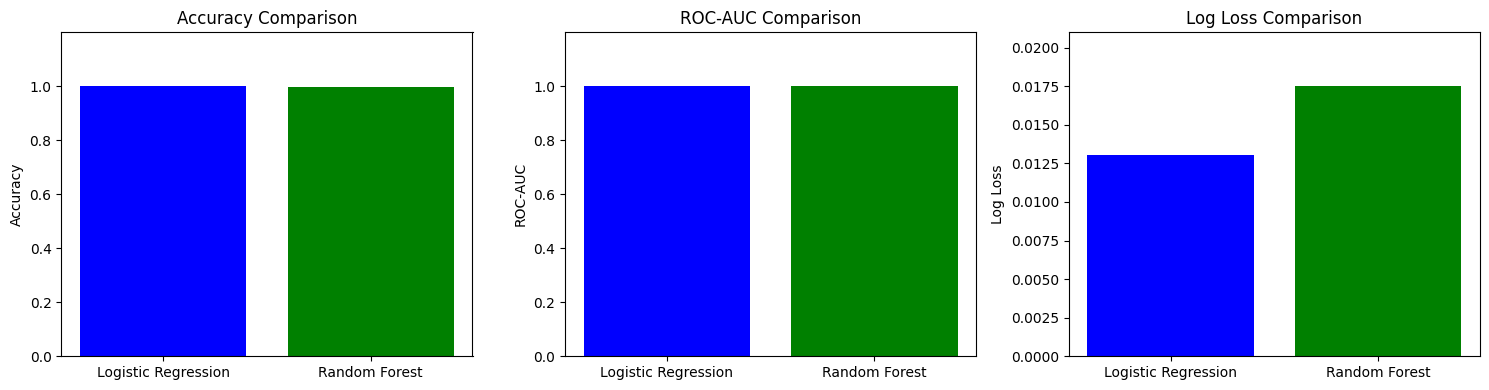


Best model based on ROC-AUC: Logistic Regression


In [8]:
# Create comparison table
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [lr_accuracy, rf_accuracy],
    'ROC-AUC': [lr_auc, rf_auc],
    'Log Loss': [lr_logloss, rf_logloss]
})

print("\n=== Model Comparison ===")
print(comparison.to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

metrics = ['Accuracy', 'ROC-AUC', 'Log Loss']
for i, metric in enumerate(metrics):
    axes[i].bar(['Logistic Regression', 'Random Forest'], 
                comparison[metric], color=['blue', 'green'])
    axes[i].set_ylabel(metric)
    axes[i].set_title(f'{metric} Comparison')
    axes[i].set_ylim([0, max(comparison[metric]) * 1.2])

plt.tight_layout()
plt.show()

# Select best model based on ROC-AUC
best_model_name = comparison.loc[comparison['ROC-AUC'].idxmax(), 'Model']
print(f"\nBest model based on ROC-AUC: {best_model_name}")


In [19]:
# Use the best performing model 
final_model = lr_model
final_scaler = scaler  # Keep scaler if you end up using Logistic Regression

def predict_expected_loss(borrower_data, loan_amount, recovery_rate=0.10):
    """
    Predict expected loss for a loan
    
    Parameters:
    - borrower_data: dict with keys matching feature names
      Example: {
          'credit_lines_outstanding': 3,
          'loan_amt_outstanding': 15000,
          'total_debt_outstanding': 25000,
          'income': 60000,
          'years_employed': 5,
          'fico_score': 680
      }
    - loan_amount: The loan amount (Exposure at Default)
    - recovery_rate: Expected recovery if default occurs (default 10%)
    
    Returns:
    - expected_loss: Expected loss in dollars
    - probability_default: Probability of default (0 to 1)
    """
    
    # Convert input to DataFrame
    input_df = pd.DataFrame([borrower_data])
    
    # Ensure columns are in correct order
    input_df = input_df[X.columns]
    input_df_scaled = pd.DataFrame(
            final_scaler.transform(input_df),
            columns=input_df.columns
        )
    # Predict probability of default
    probability_default = final_model.predict_proba(input_df_scaled)[0][1]
    
    # Calculate Loss Given Default
    lgd = 1 - recovery_rate
    
    # Calculate Expected Loss
    expected_loss = probability_default * loan_amount * lgd
    
    return expected_loss, probability_default


# Test the function
test_borrower = {
    'credit_lines_outstanding': 4,
    'loan_amt_outstanding': 20000,
    'total_debt_outstanding': 35000,
    'income': 45000,
    'years_employed': 3,
    'fico_score': 620
}

test_loan_amount = 15000

loss, pd_prob = predict_expected_loss(test_borrower, test_loan_amount)

print("\n=== Example Prediction ===")
print(f"Borrower details: {test_borrower}")
print(f"Loan amount: ${test_loan_amount:,}")
print(f"Probability of Default: {pd_prob:.2%}")
print(f"Expected Loss: ${loss:,.2f}")



=== Example Prediction ===
Borrower details: {'credit_lines_outstanding': 4, 'loan_amt_outstanding': 20000, 'total_debt_outstanding': 35000, 'income': 45000, 'years_employed': 3, 'fico_score': 620}
Loan amount: $15,000
Probability of Default: 100.00%
Expected Loss: $13,500.00


/opt/homebrew/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
